In [2]:
# Business Problem Statement

# A global e-commerce company operating across multiple regions handles end-to-end order fulfillment, including the shipment and delivery of sporting goods and other products. 
# However, inconsistent delivery performance has become a major challenge,as actual shipping times often differ from planned schedules. 
# These delays lead to poor customer satisfaction, increased late deliveries, and uncertainty in order profitability.

# The goal is to analyze delivery operations

# Identify bottlenecks
# Build a predictive system to reduce delays
# Optimize shipping decisions
# Improve overall profitability and efficiency

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))

primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]

custom_palette = viridis_colors

In [4]:
df = pd.read_csv(r"C:\Users\user\Downloads\DataCoSupplyChainDataset.csv",encoding ='latin-1')

In [6]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [7]:
df.shape

(180519, 53)

# Exploratory Data Analysis(EDA)

In [9]:
print('rows,cols:', df.shape)

rows,cols: (180519, 53)


In [10]:
print('\ncolumns:')
print(df.columns.tolist())


columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date

In [11]:
print('\nNum duplicates:', df.duplicated().sum())


Num duplicates: 0


In [12]:
print("\nMissing values (Top 10)")
print(df.isna().sum().sort_values(ascending=False).head(10))


Missing values (Top 10)
Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
dtype: int64


# Data cleaning 

In [13]:

columns_to_drop = [
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',      # identical to Order Profit Per Order
    'Product Status',         # have only one value
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Product Description',
    'Product Image',
    'Customer Email'
]
# Drop columns that are fully missing , redundent values 
df =df.drop(columns = columns_to_drop,errors='ignore')



In [14]:
df.shape

(180519, 20)

In [15]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='str')

In [16]:
# remove cancelled orders since they are not use for delivery time analysis and may have different patterns
df = df[df['Delivery Status'] != 'Shipping canceled']

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 172765 entries, 0 to 180518
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           172765 non-null  str    
 1   Days for shipping (real)       172765 non-null  int64  
 2   Days for shipment (scheduled)  172765 non-null  int64  
 3   Sales per customer             172765 non-null  float64
 4   Delivery Status                172765 non-null  str    
 5   Late_delivery_risk             172765 non-null  int64  
 6   Category Name                  172765 non-null  str    
 7   Customer Country               172765 non-null  str    
 8   Customer Segment               172765 non-null  str    
 9   Department Name                172765 non-null  str    
 10  order date (DateOrders)        172765 non-null  str    
 11  Order Item Profit Ratio        172765 non-null  float64
 12  Sales                          172765 non-null

In [80]:
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c] = pd.to_datetime(
        df[c],
        errors='coerce',
        dayfirst=False
    )

In [81]:
df.info()

<class 'pandas.DataFrame'>
Index: 172765 entries, 0 to 180518
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           172765 non-null  str           
 1   Days for shipping (real)       172765 non-null  int64         
 2   Days for shipment (scheduled)  172765 non-null  int64         
 3   Sales per customer             172765 non-null  float64       
 4   Delivery Status                172765 non-null  str           
 5   Late_delivery_risk             172765 non-null  int64         
 6   Category Name                  172765 non-null  str           
 7   Customer Country               172765 non-null  str           
 8   Customer Segment               172765 non-null  str           
 9   Department Name                172765 non-null  str           
 10  order date (DateOrders)        172765 non-null  datetime64[us]
 11  Order Item Profi

In [23]:
df = df.drop(columns = 'Order processing Tie', errors='ignore')

In [24]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [25]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='str')

In [28]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'],
    errors='coerce'
)
df['shipping date (DateOrders)'] = pd.to_datetime(
    df['shipping date (DateOrders)'],
    errors='coerce'
)

In [29]:
# Calculating order processing time and delay
df['Order processing Time'] = (df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0 
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_month'] = df['order date (DateOrders)'].dt.day_name()
df['order_month'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order processing Time,Delay,order_month
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,6.927276


In [30]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [31]:
df.columns


Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order processing Time', 'Delay', 'Is_Delayed',
       'order_month'],
      dtype='str')

In [33]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [35]:
df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0,
    'Profit',
    np.where(
        df['Order Profit Per Order'] < 0,
        'Loss',
        'Break-even'
    )
)
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

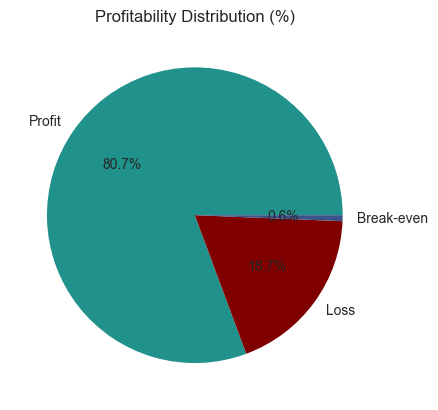

In [36]:
# Visualization of Profitability Distribution

profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [37]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)

metrics['On time Delivery %'] = (
    1 - float(metrics['Late Deliveries']) / metrics['Total Orders']
) * 100

metrics['Late Delivery %'] = (
    float(metrics['Late Deliveries']) / metrics['Total Orders']
) * 100

metrics['Total Profit'] = format_func(
    df.loc[df['Order Profit Per Order'] > 0,
           'Order Profit Per Order'].sum()
)

metrics['Total Loss due to delays'] = format_func(
    df.loc[df['Delay'] > 0,
           'Order Profit Per Order'].sum()
)

print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


# Profitability vs delivery time analysis 

In [38]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'Profitability Flag'],
      dtype='str')

In [40]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    )
    .reset_index()
)

In [41]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [43]:
delay_distribution = (
    df['Delay'].value_counts(normalize=True).sort_index() * 100).reset_index()

In [44]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


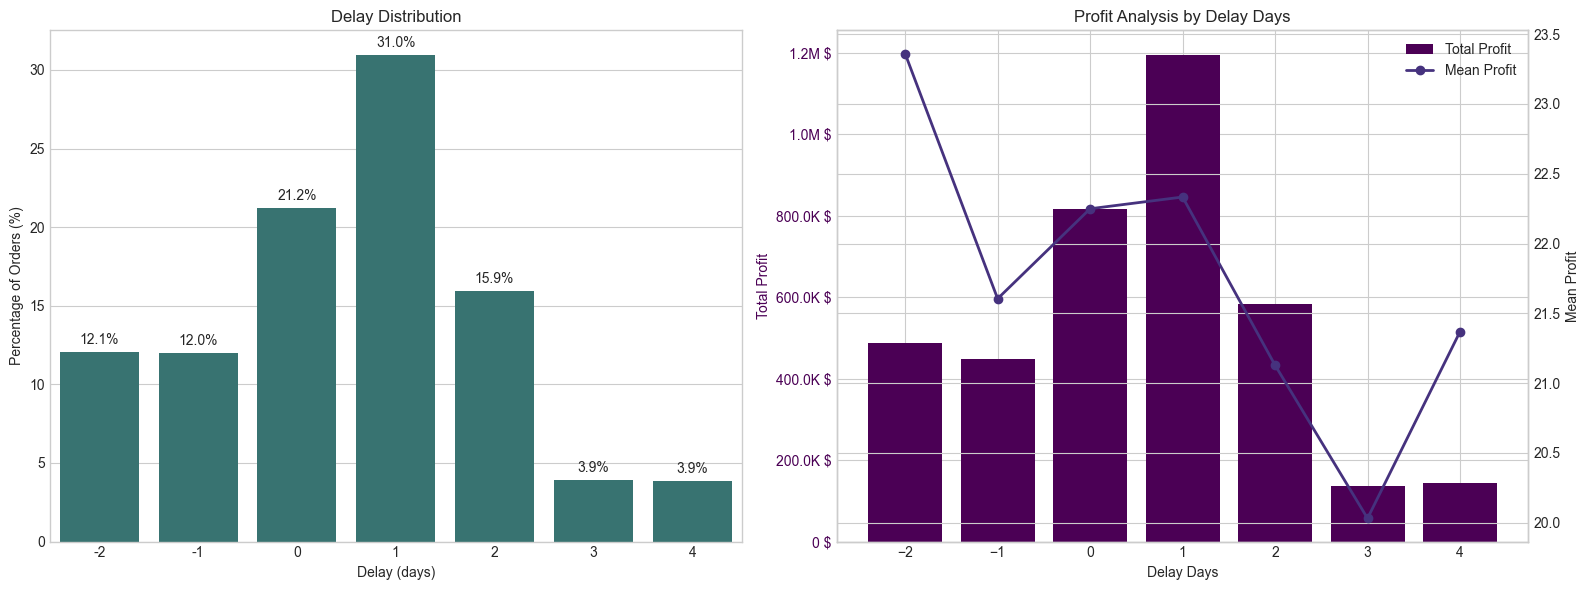

In [50]:
# Colors
accent_color = '#2E7D7A'
primary_color = '#4B0055'

# -----------------------------
# Delay Distribution
# -----------------------------
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .reset_index()
)

delay_distribution.columns = ['Delay_Days', 'Percentage']

# -----------------------------
# Profit Analysis by Delay
# -----------------------------
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(['sum', 'mean'])
    .reset_index()
)

profit_metrics.columns = [
    'Delay',
    'total_profit',
    'mean_profit'
]

# -----------------------------
# Create Figure
# -----------------------------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16,6)
)

# ====================================
# First Subplot : Delay Distribution
# ====================================

sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of Orders (%)')

# Percentage labels on bars
for bar in ax1.patches:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

# ====================================
# Second Subplot :
# Profit Analysis by Delay Days
# ====================================

# Total Profit (Bar)
ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)

ax2.set_title('Profit Analysis by Delay Days')
ax2.set_xlabel('Delay Days')
ax2.set_ylabel('Total Profit', color=primary_color)

ax2.tick_params(
    axis='y',
    labelcolor=primary_color
)

# Profit Axis Format
def format_func(value, tick_number):

    if value >= 1e6:
        return f'{value/1e6:.1f}M $'

    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'

    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(format_func)
)

# Mean Profit Line
ax3 = ax2.twinx()

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    linewidth=2,
    label='Mean Profit'
)

ax3.set_ylabel('Mean Profit')
ax3.tick_params(axis='y')

# Combined Legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()

ax2.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

plt.tight_layout()
plt.show()

# Bottleneck Detection 

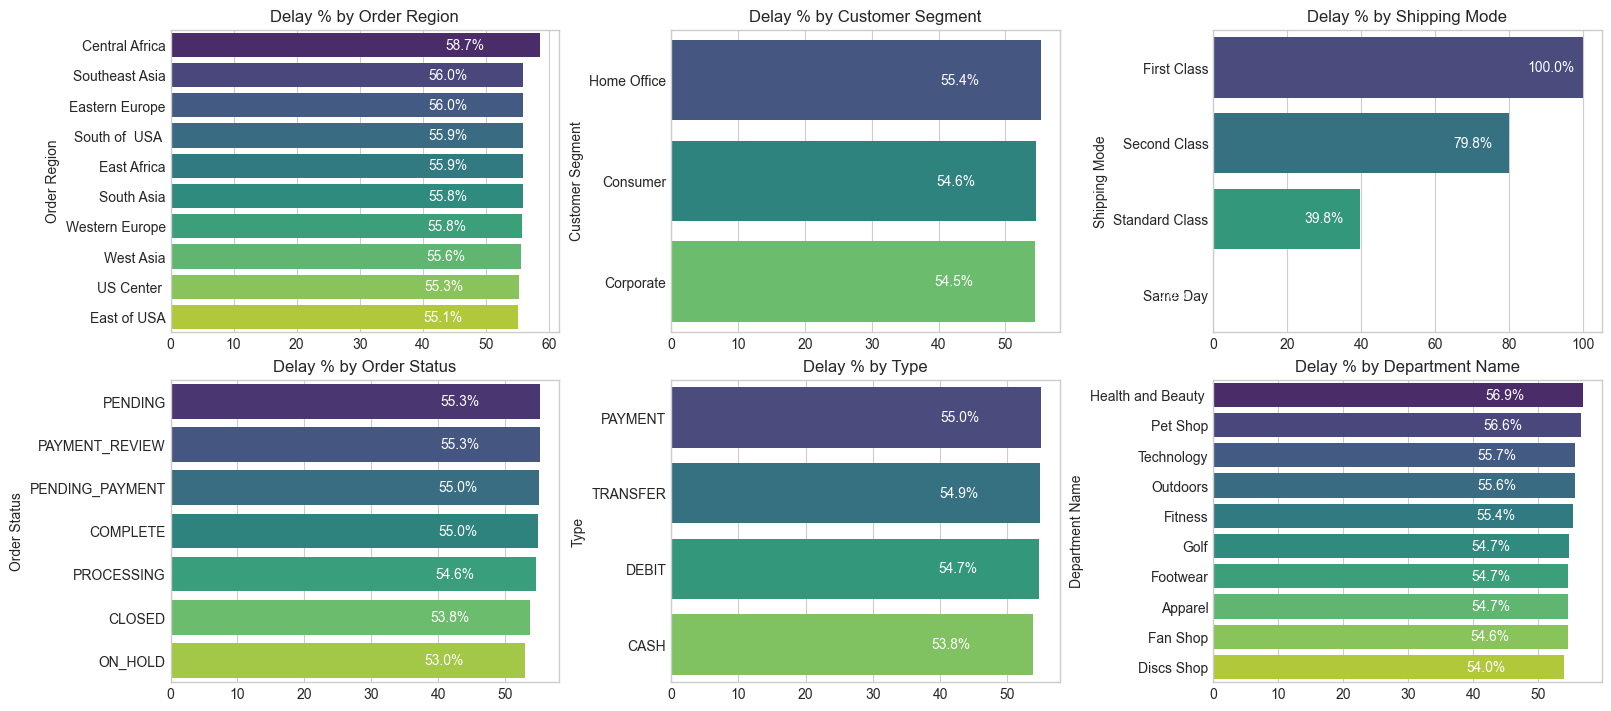

In [51]:
def compute_delay_pct_by_category(category):

    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (
        cat_df['late_orders'] /
        cat_df['total_orders']
    ) * 100

    cat_df = cat_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 7),
    constrained_layout=True
)

axes = axes.flatten()


for ax, category in zip(axes, categories):

    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():

        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

plt.show()

# Root Cause Analysis 

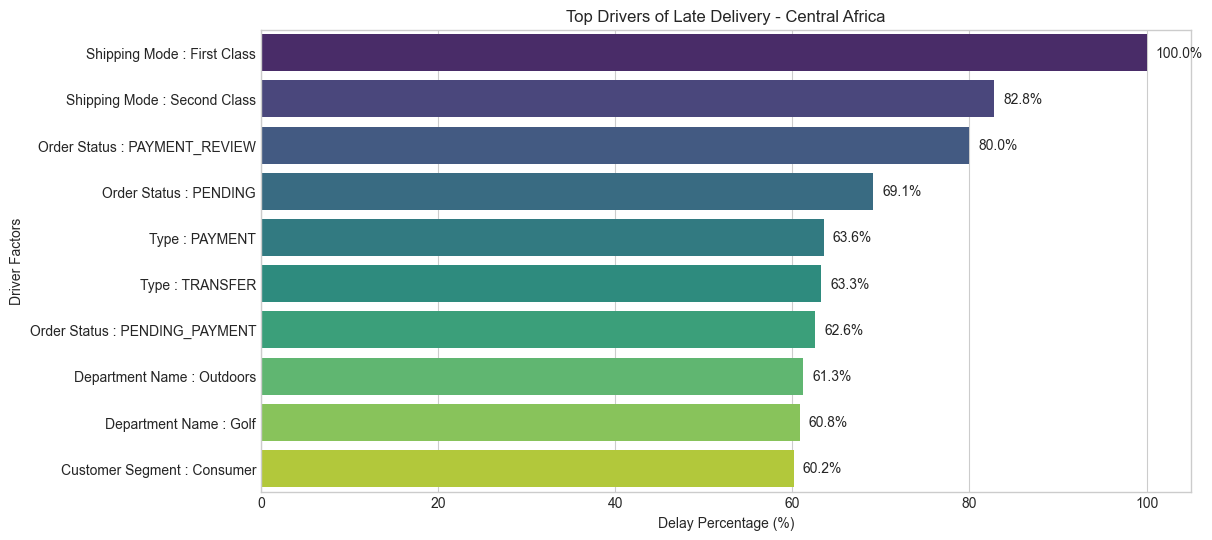

,Driver,Factor_Level,delay_pct,avg_delay,total_orders
0,Shipping Mode,Shipping Mode : First Class,100.000000,1.000000,278
2,Shipping Mode,Shipping Mode : Second Class,82.817869,2.127148,291
20,Order Status,Order Status : PAYMENT_REVIEW,80.000000,1.200000,20
21,Order Status,Order Status : PENDING,69.148936,0.574468,188
15,Type,Type : PAYMENT,63.583815,0.763006,346
16,Type,Type : TRANSFER,63.260341,0.608273,411
22,Order Status,Order Status : PENDING_PAYMENT,62.576687,0.736196,326
12,Department Name,Department Name : Outdoors,61.250000,0.800000,80
11,Department Name,Department Name : Golf,60.830861,0.673591,337
4,Customer Segment,Customer Segment : Consumer,60.150376,0.642857,798


In [69]:
def top_drivers_for_region(region):

    # Filter region
    df_region = df[df['Order Region'] == region].copy()

    if df_region.empty:
        print(f"No data found for region: {region}")
        return

    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]

    all_factors = []

    for factor in drivers:

        temp = (
            df_region
            .groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = (
            temp['late_orders']
            / temp['total_orders']
            * 100
        )

        temp['Driver'] = factor

        temp['Factor_Level'] = (
            factor + ' : ' +
            temp[factor].astype(str)
        )

        all_factors.append(
            temp[
                [
                    'Driver',
                    'Factor_Level',
                    'delay_pct',
                    'avg_delay',
                    'total_orders'
                ]
            ]
        )

    # Combine all factors
    final_df = pd.concat(
        all_factors,
        ignore_index=True
    )

    # Top 10 root causes
    top_factors = (
        final_df
        .sort_values(
            'delay_pct',
            ascending=False
        )
        .head(10)
    )

    # Visualization
    plt.figure(figsize=(12,6))

    sns.barplot(
        data=top_factors,
        x='delay_pct',
        y='Factor_Level',
        palette='viridis'
    )

    plt.title(
        f'Top Drivers of Late Delivery - {region}'
    )

    plt.xlabel('Delay Percentage (%)')
    plt.ylabel('Driver Factors')

    # Add labels
    for i, value in enumerate(top_factors['delay_pct']):

        plt.text(
            value + 1,
            i,
            f'{value:.1f}%',
            va='center'
        )

    plt.show()

    return top_factors
top_drivers_for_region('Central Africa')

# Time- Based Analysis 

In [71]:
# Delay % by Month, Day of Week, Hour
# Ensure datetime
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)'],
    errors='coerce'
)

# Create time features
df['order_month'] = df['order date (DateOrders)'].dt.month_name()
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_month['delay_pct'] = (
    delay_by_month['Is_Delayed'] * 100
)

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_day['delay_pct'] = (
    delay_by_day['Is_Delayed'] * 100
)

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_hour['delay_pct'] = (
    delay_by_hour['Is_Delayed'] * 100
)

In [74]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,April,0.545042,54.504230
1,August,0.553871,55.387128
2,December,0.552240,55.224003
3,February,0.546046,54.604550
4,January,0.542542,54.254150
5,July,0.537310,53.731048
6,June,0.547645,54.764535
7,March,0.548094,54.809390
8,May,0.549980,54.998022
9,November,0.548609,54.860878


In [75]:
delay_by_day

,order_day,Is_Delayed,delay_pct
0,Friday,0.544884,54.488442
1,Monday,0.555338,55.533838
2,Saturday,0.542619,54.261937
3,Sunday,0.551524,55.152418
4,Thursday,0.547202,54.720188
5,Tuesday,0.539841,53.984137
6,Wednesday,0.548452,54.845175


In [77]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


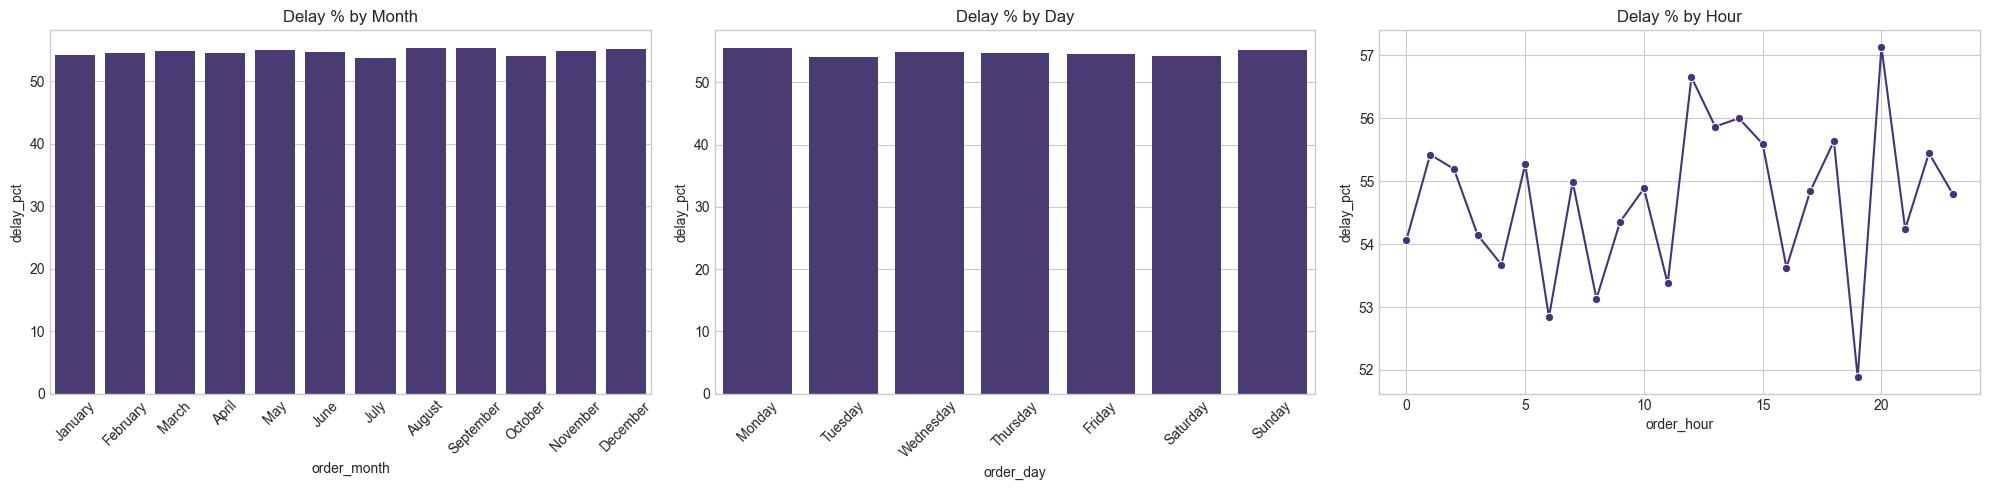

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create time columns if not already present
df['order_month'] = df['order date (DateOrders)'].dt.month_name()
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

# ----------------------------
# Delay % by Month
# ----------------------------

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

delay_by_month['order_month'] = pd.Categorical(
    delay_by_month['order_month'],
    categories=month_order,
    ordered=True
)

delay_by_month = delay_by_month.sort_values('order_month')

# ----------------------------
# Delay % by Day
# ----------------------------

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')

# ----------------------------
# Delay % by Hour
# ----------------------------

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

# ----------------------------
# Visualization
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Month
sns.barplot(
    data=delay_by_month,
    x='order_month',
    y='delay_pct',
    ax=axes[0]
)

axes[0].set_title('Delay % by Month')
axes[0].tick_params(axis='x', rotation=45)

# Day
sns.barplot(
    data=delay_by_day,
    x='order_day',
    y='delay_pct',
    ax=axes[1]
)

axes[1].set_title('Delay % by Day')
axes[1].tick_params(axis='x', rotation=45)

# Hour
sns.lineplot(
    data=delay_by_hour,
    x='order_hour',
    y='delay_pct',
    marker='o',
    ax=axes[2]
)

axes[2].set_title('Delay % by Hour')

plt.tight_layout()
plt.show()